In [141]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [142]:
df=pd.read_csv("diabetes.csv")

In [143]:
df.shape

(768, 9)

In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [145]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [146]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [147]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [148]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [149]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [150]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
763    False
764    False
765    False
766    False
767    False
Length: 768, dtype: bool

In [151]:

cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[cols] = df[cols].replace(0, np.nan)
print("Missing values before filling:")
print(df.isnull().sum())

Missing values before filling:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [152]:

df.fillna(df.median(), inplace=True)
print("\nMissing values after filling:")
print(df.isnull().sum())


Missing values after filling:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


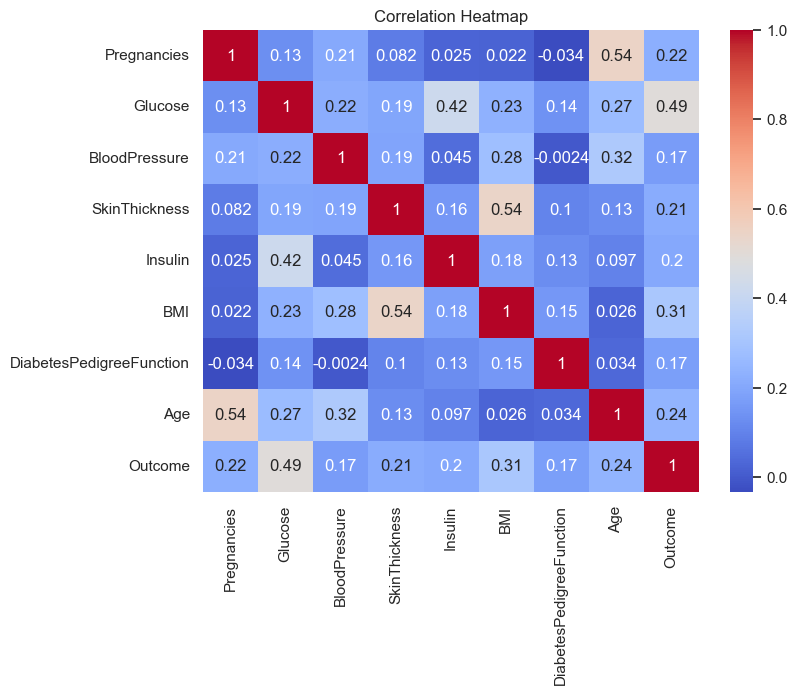

In [153]:

sns.set(style="whitegrid")

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

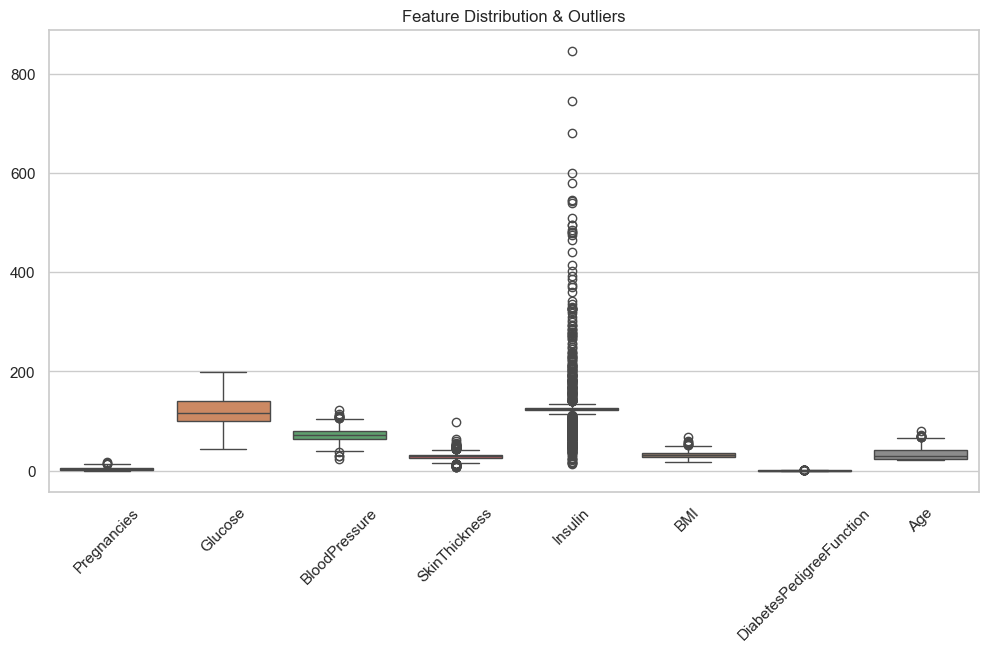

In [154]:

plt.figure(figsize=(12,6))
sns.boxplot(data=df.drop("Outcome", axis=1))
plt.xticks(rotation=45)
plt.title("Feature Distribution & Outliers")
plt.show()

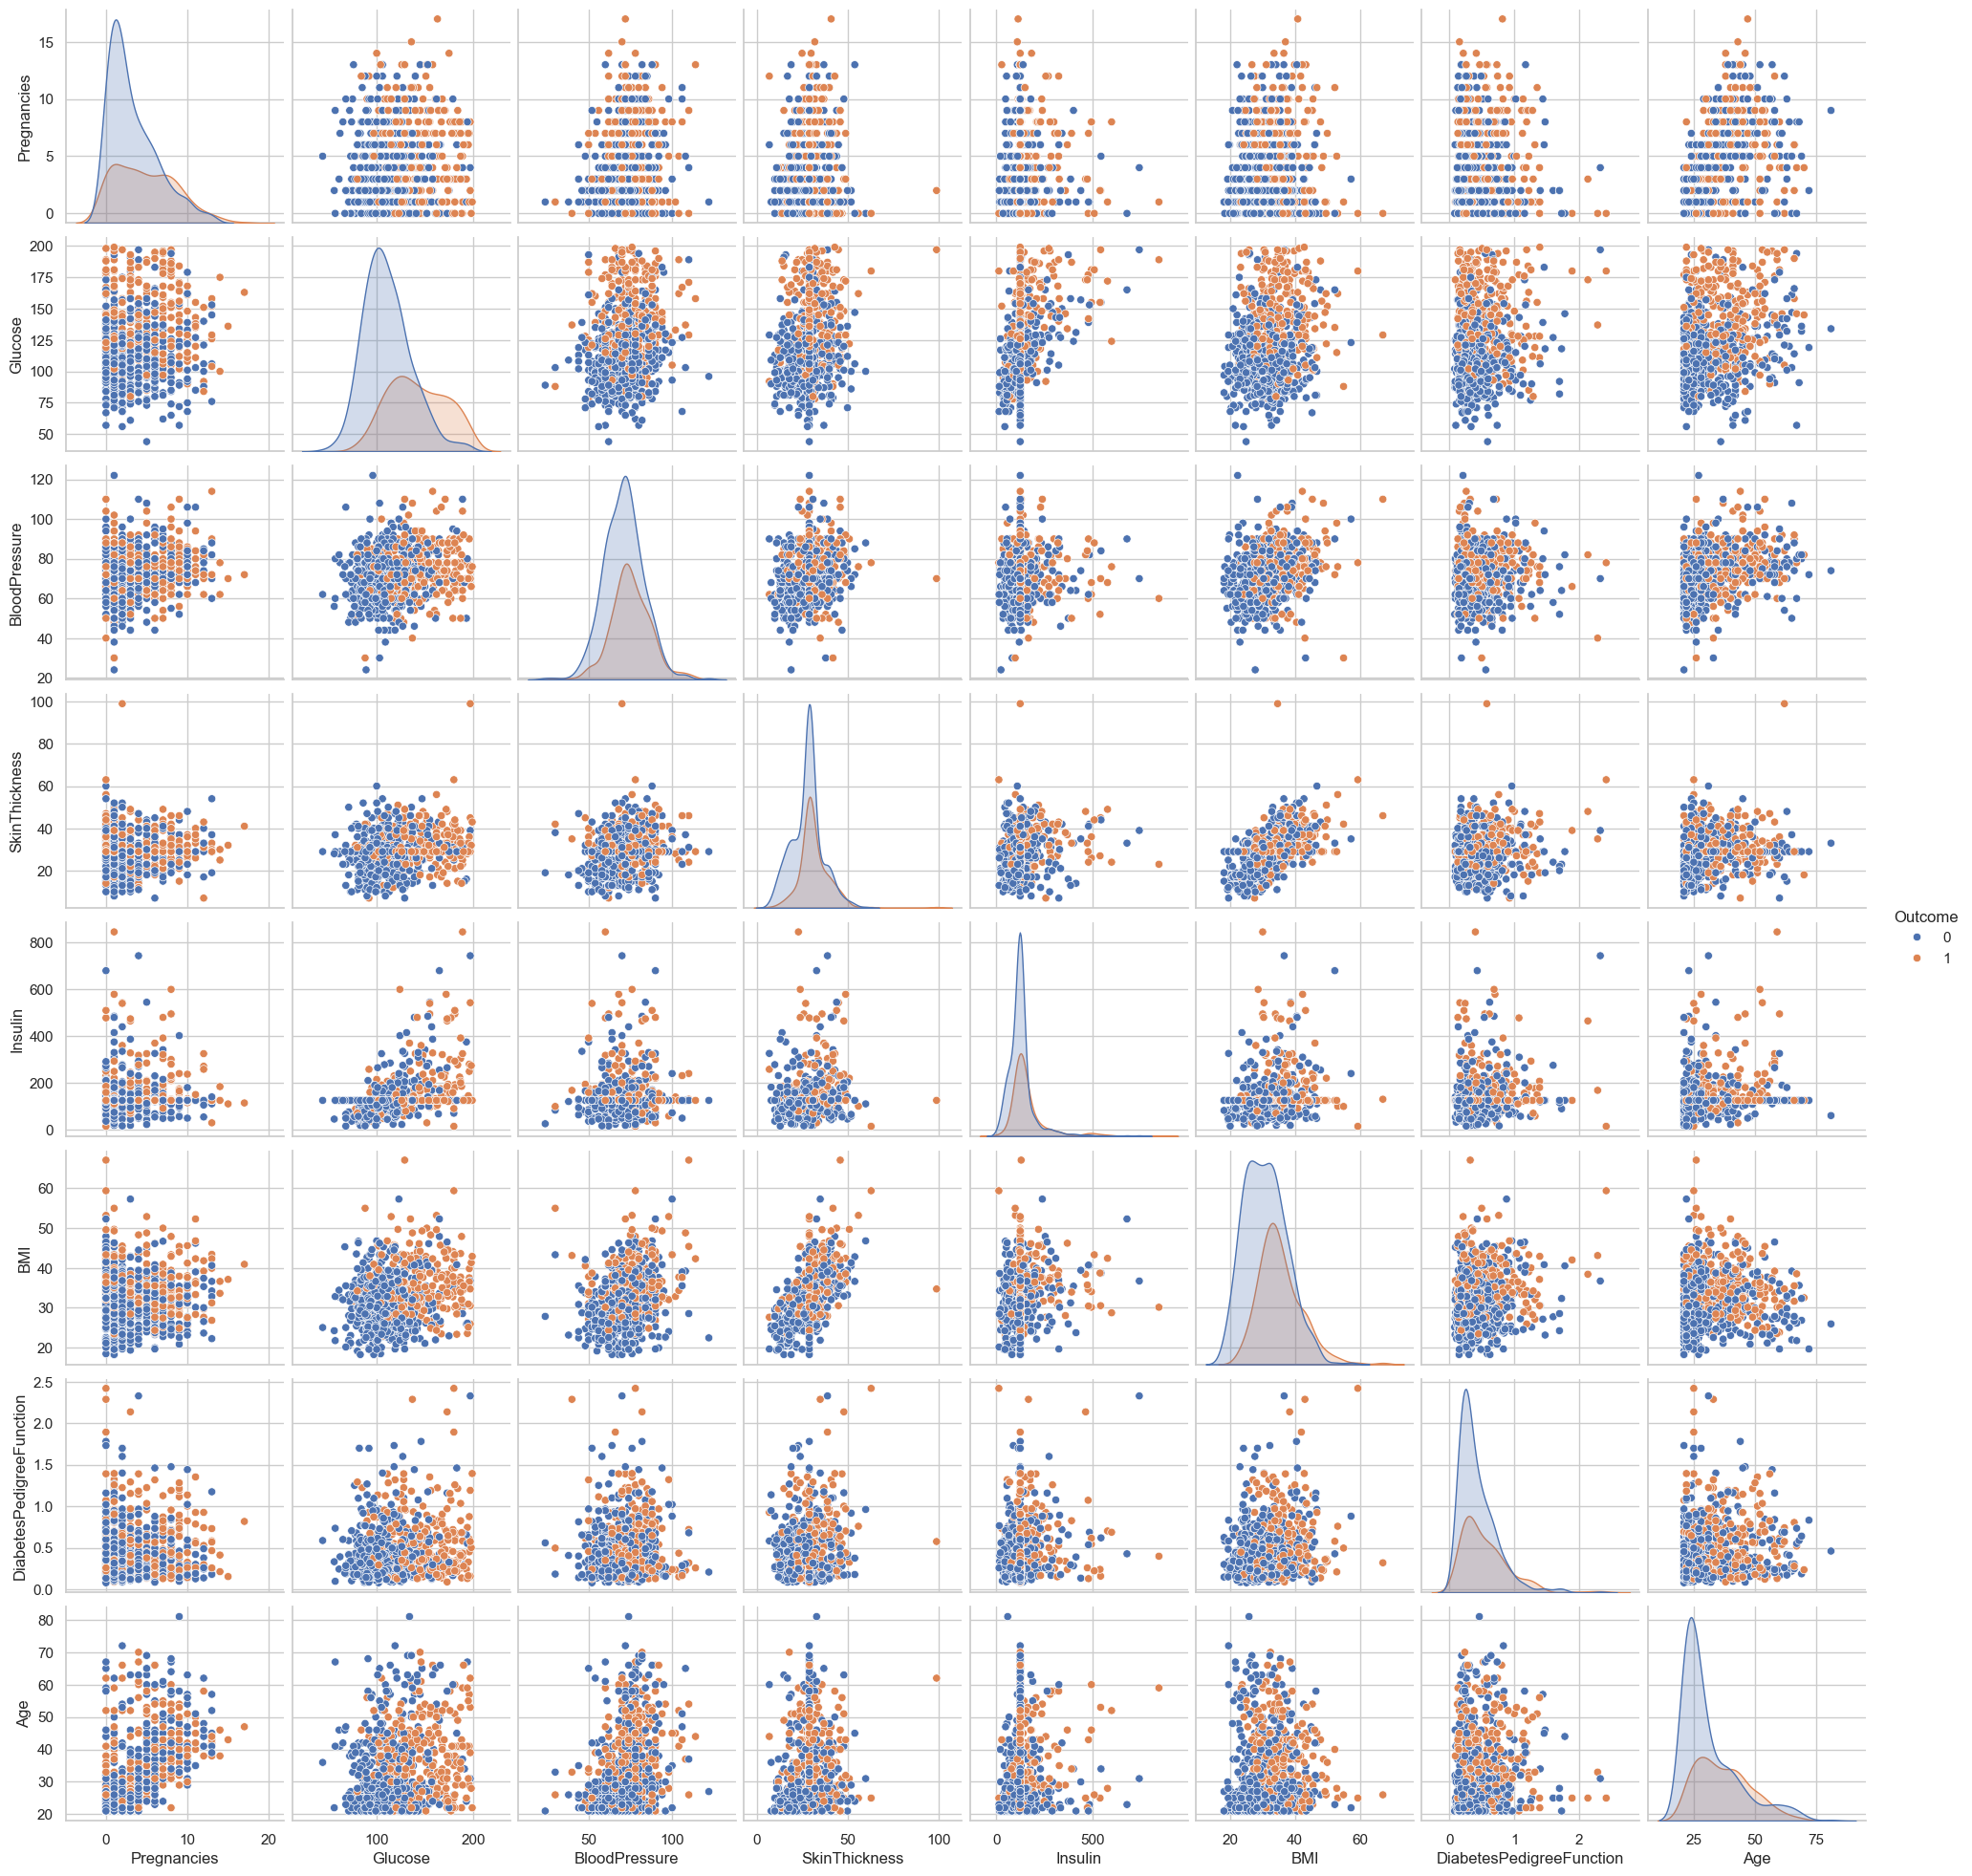

In [155]:

sns.pairplot(df, hue="Outcome", diag_kind="kde")
plt.show()

# Data Preprocessing

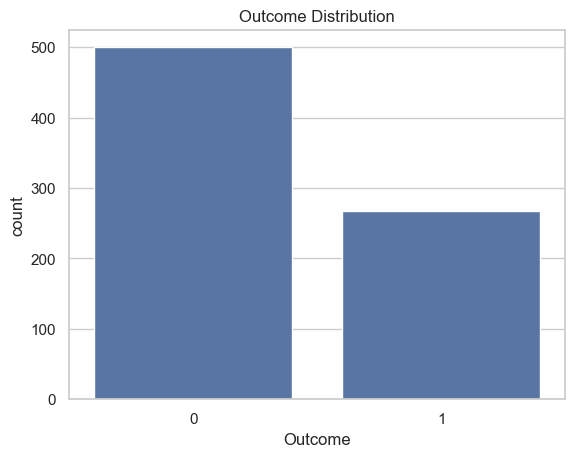

In [156]:

sns.countplot(x='Outcome', data=df)
plt.title("Outcome Distribution")
plt.show()

In [157]:
# Split Data 
from sklearn.model_selection import train_test_split

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [158]:
# ScalING Features 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [159]:
print("Cleaned and Visualization of  Data")
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Cleaned and Visualization of  Data
Training set shape: (614, 8)
Testing set shape: (154, 8)


# KNN 

In [160]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [161]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [162]:
y_pred = knn.predict(X_test)

In [163]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7207792207792207

Confusion Matrix:
 [[74 25]
 [18 37]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.75      0.77        99
           1       0.60      0.67      0.63        55

    accuracy                           0.72       154
   macro avg       0.70      0.71      0.70       154
weighted avg       0.73      0.72      0.72       154



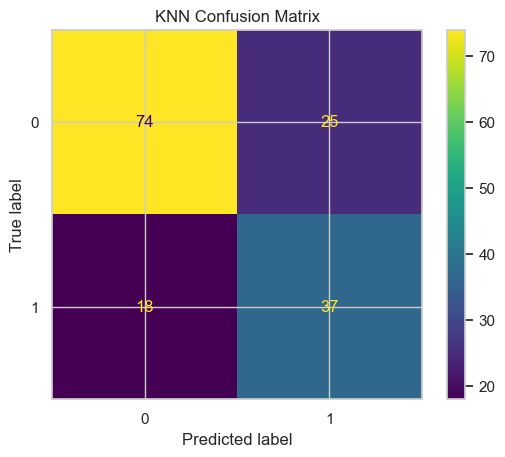

In [164]:
ConfusionMatrixDisplay.from_estimator(knn, X_test, y_test)
plt.title("KNN Confusion Matrix")
plt.show()

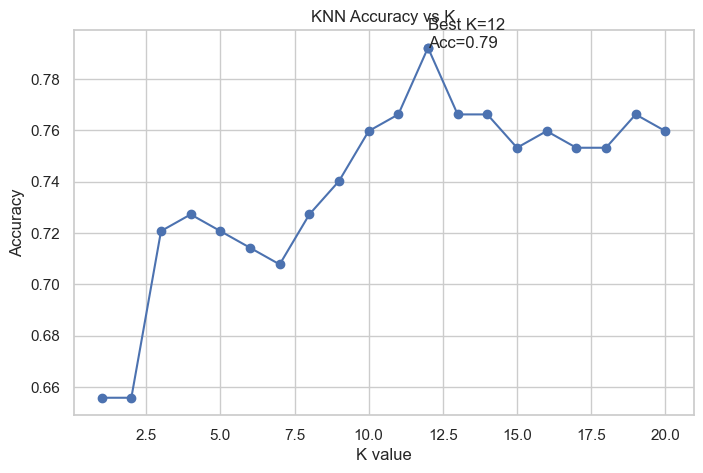

In [165]:
sns.set(style="whitegrid")

accuracies = []

# Try K values from 1 to 20
k_values = range(1, 21)

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    accuracies.append(acc)

# Find best K
best_k = k_values[accuracies.index(max(accuracies))]
best_acc = max(accuracies)

# Plot
plt.figure(figsize=(8,5))
plt.plot(k_values, accuracies, marker='o')
plt.scatter(best_k, best_acc)  # highlight best point

# Labels
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K")

# Show best value
plt.text(best_k, best_acc, f"Best K={best_k}\nAcc={best_acc:.2f}")

plt.show()

In [166]:
# TakING input from user
print("Enter patient details:")

preg = float(input("Pregnancies: "))
glucose = float(input("Glucose: "))
bp = float(input("Blood Pressure: "))
skin = float(input("Skin Thickness: "))
insulin = float(input("Insulin: "))
bmi = float(input("BMI: "))
dpf = float(input("Diabetes Pedigree Function: "))
age = float(input("Age: "))

# Put inputs into array (2D format required)
user_data = [[preg, glucose, bp, skin, insulin, bmi, dpf, age]]

# Convert to DataFrame (BEST PRACTICE)
import pandas as pd

columns = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
           "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

user_df = pd.DataFrame(user_data, columns=columns)

# Scale input (IMPORTANT)
user_data_scaled = scaler.transform(user_df)

# Predict using trained KNN model
prediction = knn.predict(user_data_scaled)

# Output result
if prediction[0] == 1:
    print("\nResult: The patient is Diabetic")
else:
    print("\nResult: The patient is Not Diabetic")

Enter patient details:


Pregnancies:  7
Glucose:  5
Blood Pressure:  45
Skin Thickness:  10
Insulin:  18
BMI:  25
Diabetes Pedigree Function:  20
Age:  45



Result: The patient is Diabetic


In [167]:
# Combine X and y
df = pd.DataFrame(X, columns=X.columns)
df['target'] = y

# Calculate correlation
corr = df.corr()['target'].drop('target')

# Convert to DataFrame (like SVM)
feature_importance = pd.DataFrame({
    'Feature': corr.index,
    'Importance': corr.values
})

# Sort values
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Print result
print(feature_importance)

                    Feature  Importance
1                   Glucose    0.492782
5                       BMI    0.312038
7                       Age    0.238356
0               Pregnancies    0.221898
3             SkinThickness    0.214873
4                   Insulin    0.203790
6  DiabetesPedigreeFunction    0.173844
2             BloodPressure    0.165723


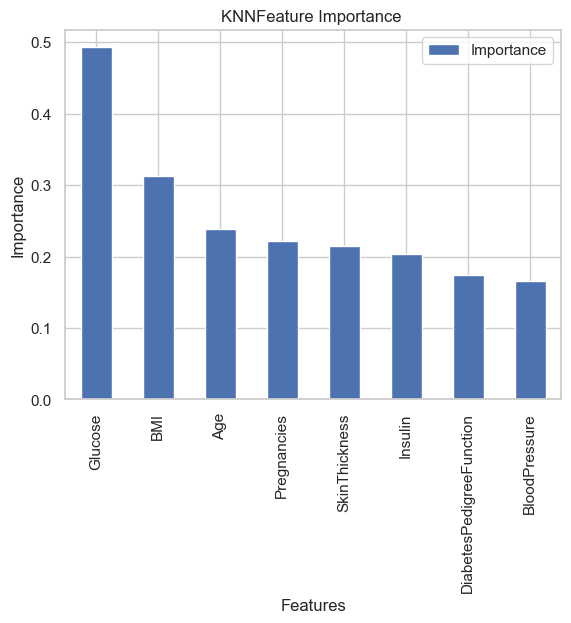

In [168]:
feature_importance.plot(kind='bar', x='Feature', y='Importance')
plt.title("KNNFeature Importance ")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

# SVM

In [169]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [170]:
svm_model = SVC(kernel='linear')   # you can also try 'rbf'
svm_model.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [171]:
y_pred = svm_model.predict(X_test)

In [172]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7532467532467533

Confusion Matrix:
 [[82 17]
 [21 34]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



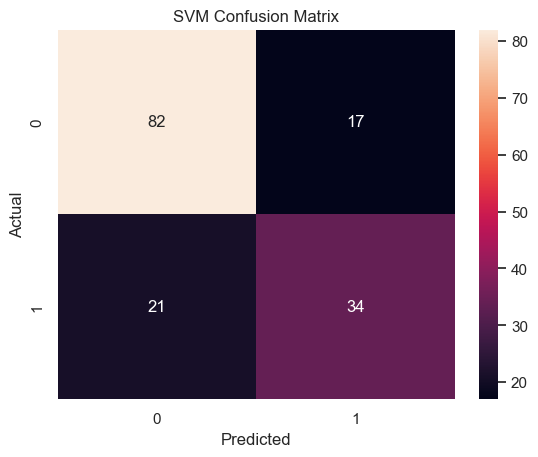

In [173]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [174]:
kernels = ['linear', 'rbf', 'poly']
accuracies = []

for k in kernels:
    model = SVC(kernel=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    

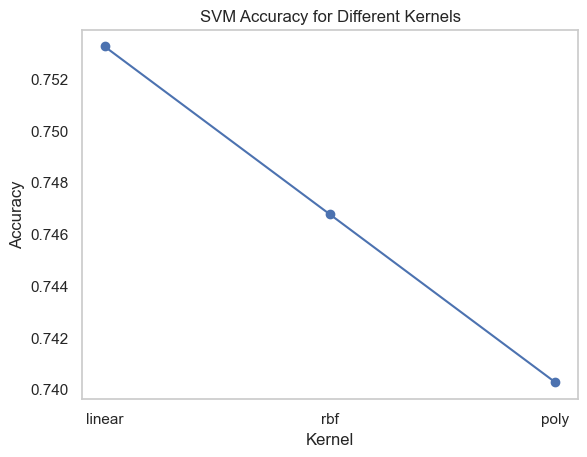

In [175]:
plt.figure()
plt.plot(kernels, accuracies, marker='o')
plt.xlabel("Kernel")
plt.ylabel("Accuracy")
plt.title("SVM Accuracy for Different Kernels")
plt.grid()
plt.show()

In [176]:
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

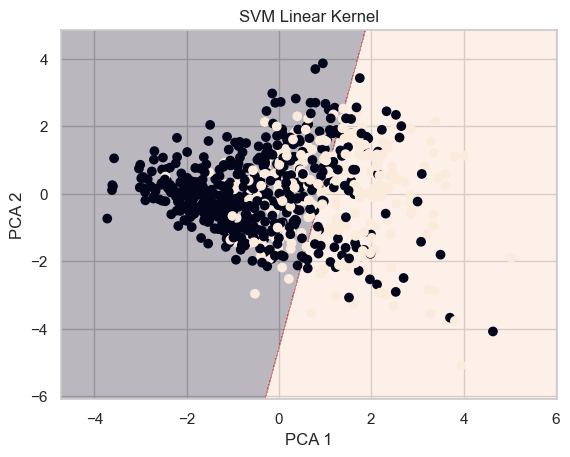

In [177]:
model = SVC(kernel='linear')
model.fit(X_pca, y)

plt.figure()

x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)

plt.title("SVM Linear Kernel")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

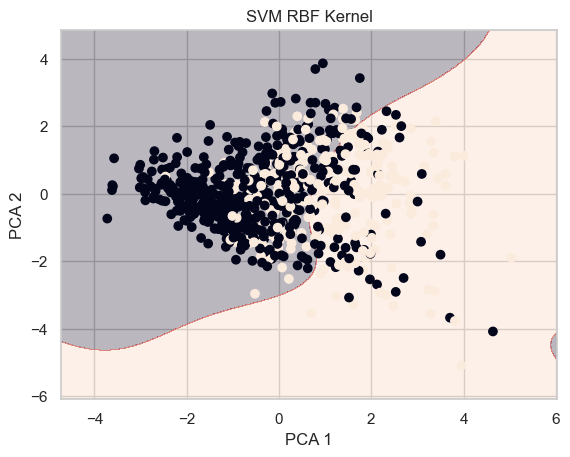

In [178]:
model = SVC(kernel='rbf')
model.fit(X_pca, y)

plt.figure()

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)

plt.title("SVM RBF Kernel")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

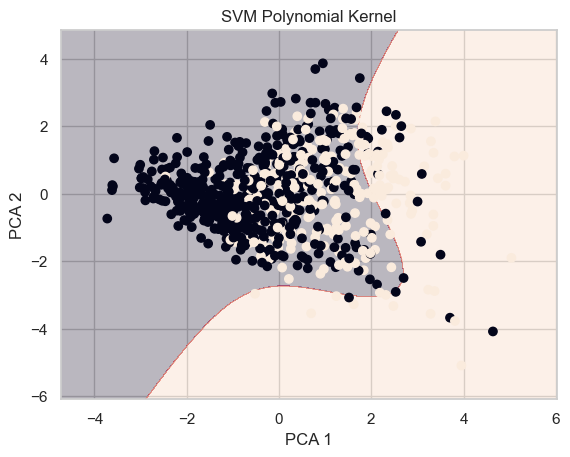

In [179]:
model = SVC(kernel='poly', degree=3)
model.fit(X_pca, y)

plt.figure()

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)

plt.title("SVM Polynomial Kernel")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [180]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

kernels = ['linear', 'rbf', 'poly']
accuracy_results = {}

for k in kernels:
    model = SVC(kernel=k)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    accuracy_results[k] = acc
for k, acc in accuracy_results.items():
    print(f"{k} Kernel Accuracy: {acc}")

linear Kernel Accuracy: 0.7532467532467533
rbf Kernel Accuracy: 0.7467532467532467
poly Kernel Accuracy: 0.7402597402597403


                    Feature  Importance
1                   Glucose    0.807905
5                       BMI    0.556752
7                       Age    0.305994
0               Pregnancies    0.206759
6  DiabetesPedigreeFunction    0.130656
3             SkinThickness   -0.052061
4                   Insulin   -0.078358
2             BloodPressure   -0.120500


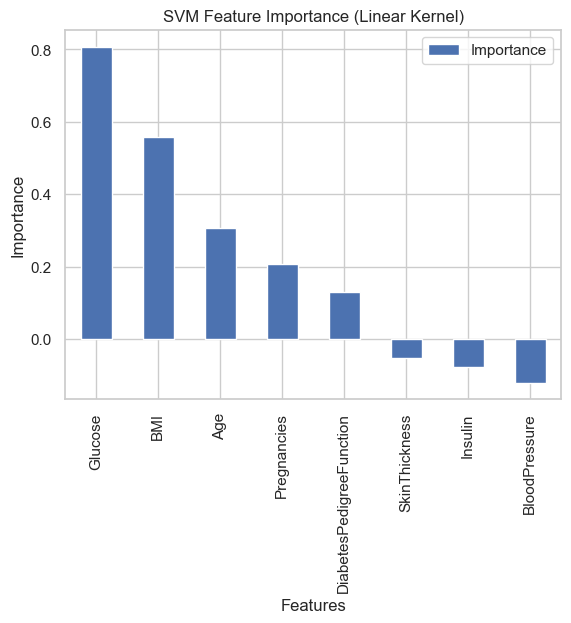

In [181]:

importance = svm_model.coef_[0]

# Put in DataFrame
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sort
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance)
feature_importance.plot(kind='bar', x='Feature', y='Importance')
plt.title("SVM Feature Importance (Linear Kernel)")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

# DECISION TREE

In [182]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [183]:
dt_model = DecisionTreeClassifier(max_depth=15,random_state=42)
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [184]:
y_pred = dt_model.predict(X_test)

In [185]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7142857142857143

Confusion Matrix:
 [[75 24]
 [20 35]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.76      0.77        99
           1       0.59      0.64      0.61        55

    accuracy                           0.71       154
   macro avg       0.69      0.70      0.69       154
weighted avg       0.72      0.71      0.72       154



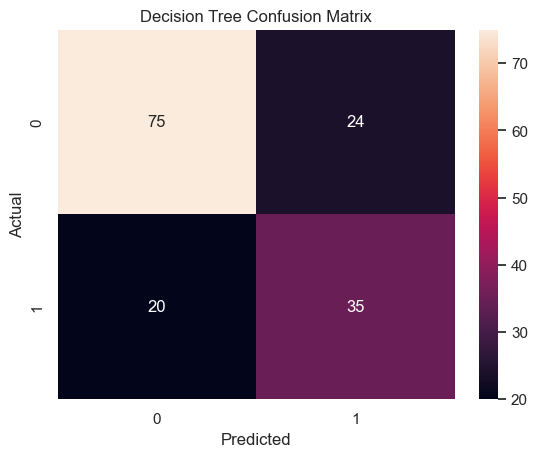

In [186]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [187]:
depth_values = range(1, 21)
accuracies = []

for d in depth_values:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    accuracies.append(acc)

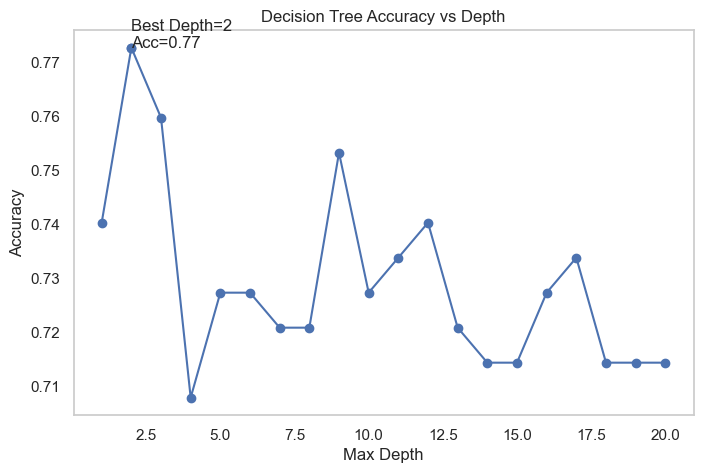

In [188]:
sns.set(style="whitegrid")

# Find best depth
best_depth = depth_values[accuracies.index(max(accuracies))]
best_acc = max(accuracies)

plt.figure(figsize=(8,5))

# Line + markers
plt.plot(depth_values, accuracies, marker='o')

# Highlight best point
plt.scatter(best_depth, best_acc)

# Labels and title
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Accuracy vs Depth")

# Show best value on graph
plt.text(best_depth, best_acc, f"Best Depth={best_depth}\nAcc={best_acc:.2f}")

# Grid
plt.grid()

plt.show()

                    Feature  Importance
1                   Glucose    0.349826
5                       BMI    0.164622
7                       Age    0.144769
6  DiabetesPedigreeFunction    0.125017
4                   Insulin    0.086476
2             BloodPressure    0.060192
3             SkinThickness    0.051929
0               Pregnancies    0.017169


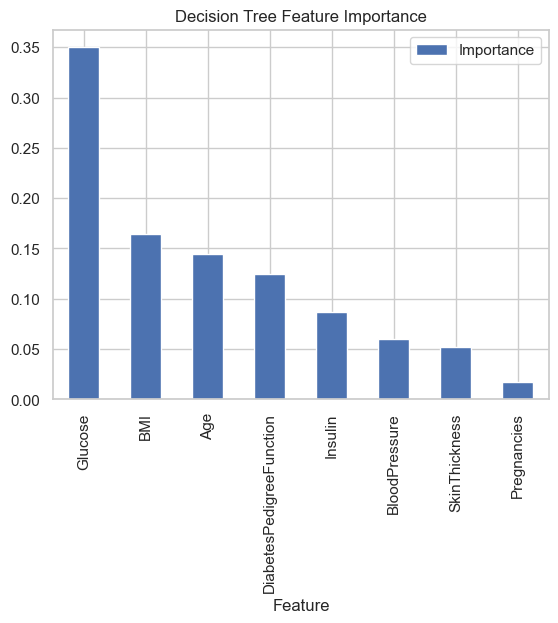

In [189]:

importance = dt_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance)

feature_importance.plot(kind='bar', x='Feature', y='Importance')
plt.title("Decision Tree Feature Importance")
plt.show()

# COMPARSION 

In [190]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [191]:
knn = KNeighborsClassifier(n_neighbors=5)
svm = SVC(kernel='linear')
dt = DecisionTreeClassifier(max_depth=15, random_state=42)

In [192]:
knn.fit(X_train, y_train)
svm.fit(X_train, y_train)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [193]:
knn_pred = knn.predict(X_test)
svm_pred = svm.predict(X_test)
dt_pred = dt.predict(X_test)

In [194]:
results = pd.DataFrame({
    'Model': ['KNN', 'SVM', 'Decision Tree'],
    
    'Accuracy': [
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, dt_pred)
    ],
    
    'Precision': [
        precision_score(y_test, knn_pred),
        precision_score(y_test, svm_pred),
        precision_score(y_test, dt_pred)
    ],
    
    'Recall': [
        recall_score(y_test, knn_pred),
        recall_score(y_test, svm_pred),
        recall_score(y_test, dt_pred)
    ],
    
    'F1 Score': [
        f1_score(y_test, knn_pred),
        f1_score(y_test, svm_pred),
        f1_score(y_test, dt_pred)
    ]
})

print(results)

           Model  Accuracy  Precision    Recall  F1 Score
0            KNN  0.720779   0.596774  0.672727  0.632479
1            SVM  0.753247   0.666667  0.618182  0.641509
2  Decision Tree  0.714286   0.593220  0.636364  0.614035


<Figure size 800x500 with 0 Axes>

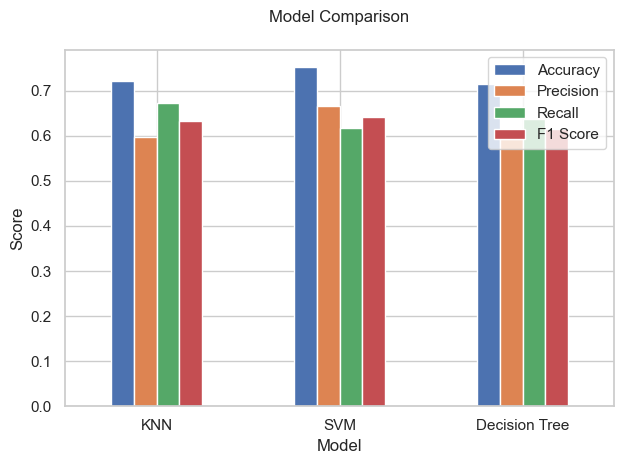

In [195]:
plt.figure(figsize=(8,5))

ax = results.set_index('Model').plot(kind='bar')

ax.set_title("Model Comparison", pad=20)
ax.set_ylabel("Score")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

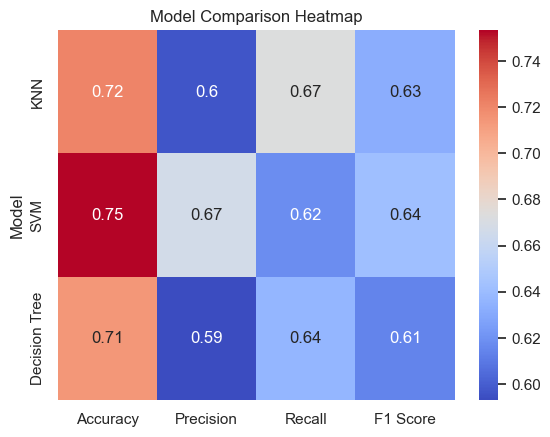

In [196]:
plt.figure()
sns.heatmap(results.set_index('Model'), annot=True, cmap='coolwarm')

plt.title("Model Comparison Heatmap")
plt.show()

# Ensemble

In [197]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

ensemble = VotingClassifier(
    estimators=[
        ('knn', knn),
        ('svm', svm),
        ('dt', dt)
    ],
    voting='hard'   # majority voting
)

ensemble.fit(X_train, y_train)


ensemble_pred = ensemble.predict(X_test)

In [198]:
print("Ensemble Results:")
print("Accuracy:", accuracy_score(y_test, ensemble_pred))
print("Precision:", precision_score(y_test, ensemble_pred))
print("Recall:", recall_score(y_test, ensemble_pred))
print("F1 Score:", f1_score(y_test, ensemble_pred))

Ensemble Results:
Accuracy: 0.7597402597402597
Precision: 0.6666666666666666
Recall: 0.6545454545454545
F1 Score: 0.6605504587155964


In [199]:
results = pd.DataFrame({
    'Model': ['KNN', 'SVM', 'Decision Tree', 'Ensemble'],

    'Accuracy': [
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, ensemble_pred)
    ],

    'Precision': [
        precision_score(y_test, knn_pred),
        precision_score(y_test, svm_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, ensemble_pred)
    ],

    'Recall': [
        recall_score(y_test, knn_pred),
        recall_score(y_test, svm_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, ensemble_pred)
    ],

    'F1 Score': [
        f1_score(y_test, knn_pred),
        f1_score(y_test, svm_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, ensemble_pred)
    ]
})

print(results)

           Model  Accuracy  Precision    Recall  F1 Score
0            KNN  0.720779   0.596774  0.672727  0.632479
1            SVM  0.753247   0.666667  0.618182  0.641509
2  Decision Tree  0.714286   0.593220  0.636364  0.614035
3       Ensemble  0.759740   0.666667  0.654545  0.660550


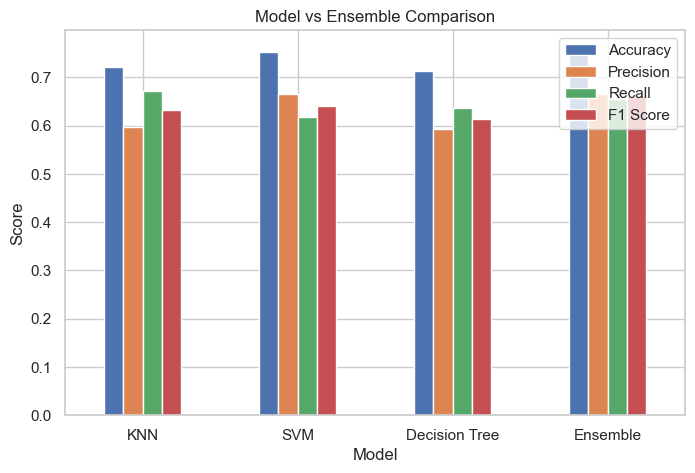

In [200]:
results.set_index('Model').plot(kind='bar', figsize=(8,5))
plt.title("Model vs Ensemble Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

<Figure size 600x500 with 0 Axes>

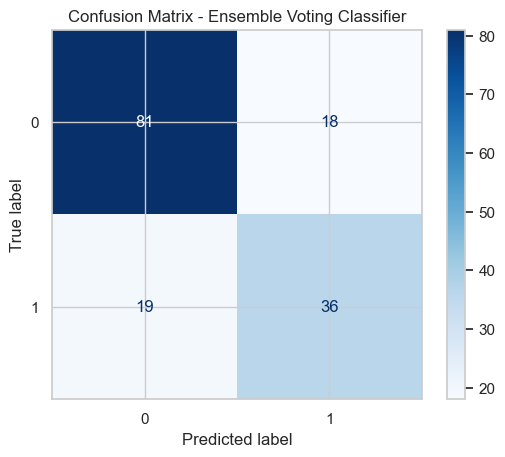

In [201]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test, ensemble_pred)

# Display Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(6,5))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Ensemble Voting Classifier")
plt.show()

In [203]:
# TakING input from user
print("Enter patient details:")

preg = float(input("Pregnancies: "))
glucose = float(input("Glucose: "))
bp = float(input("Blood Pressure: "))
skin = float(input("Skin Thickness: "))
insulin = float(input("Insulin: "))
bmi = float(input("BMI: "))
dpf = float(input("Diabetes Pedigree Function: "))
age = float(input("Age: "))

user_data = [[preg, glucose, bp, skin, insulin, bmi, dpf, age]]

import pandas as pd

columns = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
           "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

user_df = pd.DataFrame(user_data, columns=columns)

user_data_scaled = scaler.transform(user_df)

prediction = ensemble.predict(user_data_scaled)

if prediction[0] == 1:
    print("\nResult: The patient is Diabetic")
else:
    print("\nResult: The patient is Not Diabetic")

Enter patient details:


Pregnancies:  45
Glucose:  45
Blood Pressure:  5
Skin Thickness:  5
Insulin:  5
BMI:  5
Diabetes Pedigree Function:  5
Age:  4



Result: The patient is Not Diabetic
